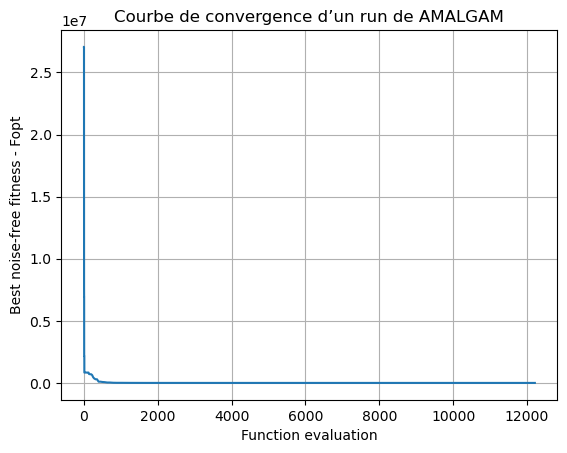

In [5]:
import matplotlib.pyplot as plt

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

data = []
start = False

for line in lines:
    line = line.strip()
    
    # Début du premier run
    if line.startswith("%") and not start:
        start = True
        continue
    
    # Stop au deuxième %
    if line.startswith("%") and start:
        break
    
    # Ajouter les lignes du run
    if start and line:
        values = line.split()
        data.append(values)

# Extraire colonnes
x = [float(row[0]) for row in data]  # evaluation
y = [float(row[2]) for row in data]  # best noise-free fitness

# Graph
plt.plot(x, y)

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbe de convergence d’un run de AMALGAM")
plt.grid()
plt.show()

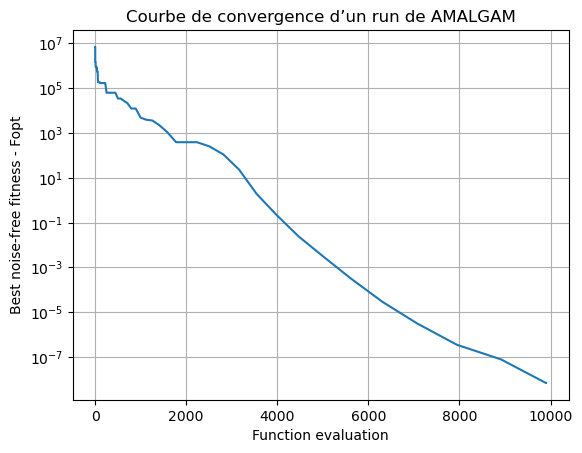

In [4]:
plt.plot(x, y)
plt.yscale("log")
plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbe de convergence d’un run de AMALGAM")
plt.grid()
plt.show()

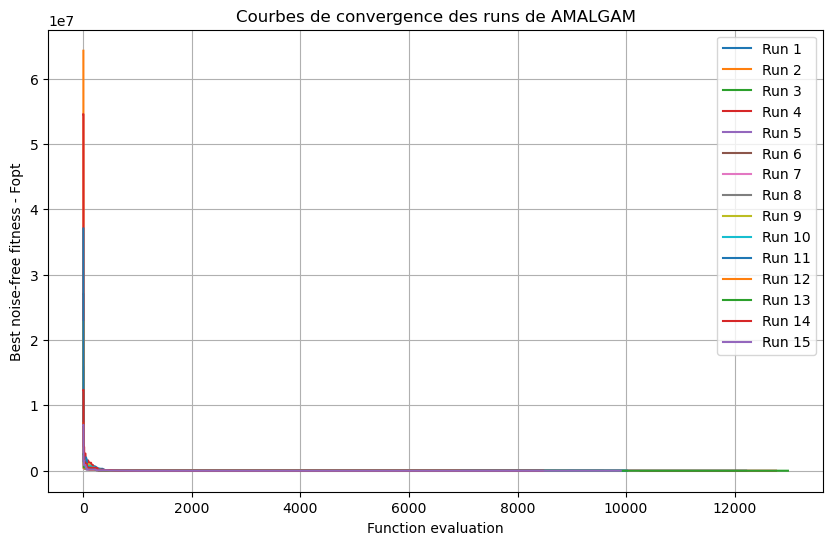

In [2]:
import matplotlib.pyplot as plt

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    # Si on trouve %, on commence un nouveau run
    if line.startswith("%"):
        if current_run:          # sauvegarder le run précédent
            runs.append(current_run)
            current_run = []
    else:
        if line:                 # ignorer les lignes vides
            current_run.append(line.split())

# Ajouter le dernier run
if current_run:
    runs.append(current_run)

# Tracer tous les runs
plt.figure(figsize=(10, 6))

for i, run in enumerate(runs):
    x = [float(row[0]) for row in run]
    y = [float(row[2]) for row in run]
    plt.plot(x, y, label=f"Run {i+1}")

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbes de convergence des runs de AMALGAM")
plt.legend()
plt.grid()
plt.show()

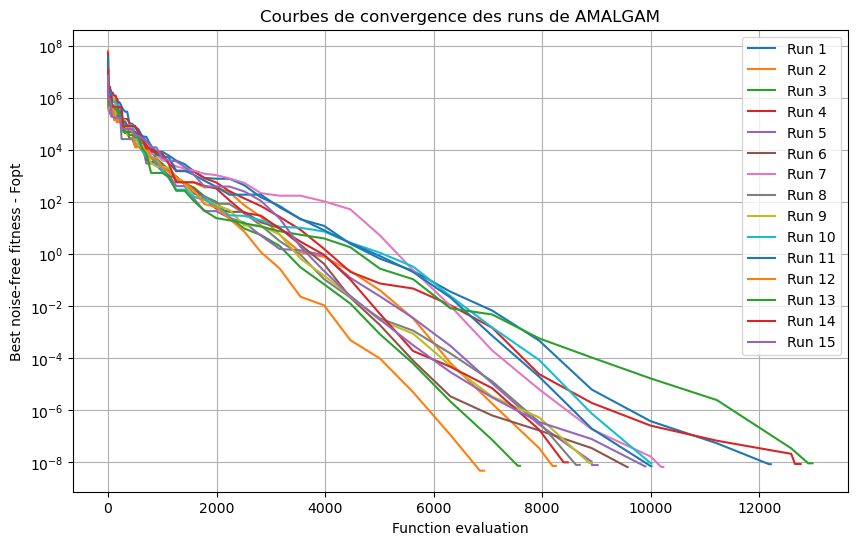

In [22]:
import matplotlib.pyplot as plt

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    # Si on trouve %, on commence un nouveau run
    if line.startswith("%"):
        if current_run:          # sauvegarder le run précédent
            runs.append(current_run)
            current_run = []
    else:
        if line:                 # ignorer les lignes vides
            current_run.append(line.split())

# Ajouter le dernier run
if current_run:
    runs.append(current_run)

# Tracer tous les runs
plt.figure(figsize=(10, 6))

for i, run in enumerate(runs):
    x = [float(row[0]) for row in run]
    y = [float(row[2]) for row in run]
    plt.plot(x, y, label=f"Run {i+1}")

plt.yscale("log")
plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbes de convergence des runs de AMALGAM")
plt.legend()
plt.grid()
plt.show()



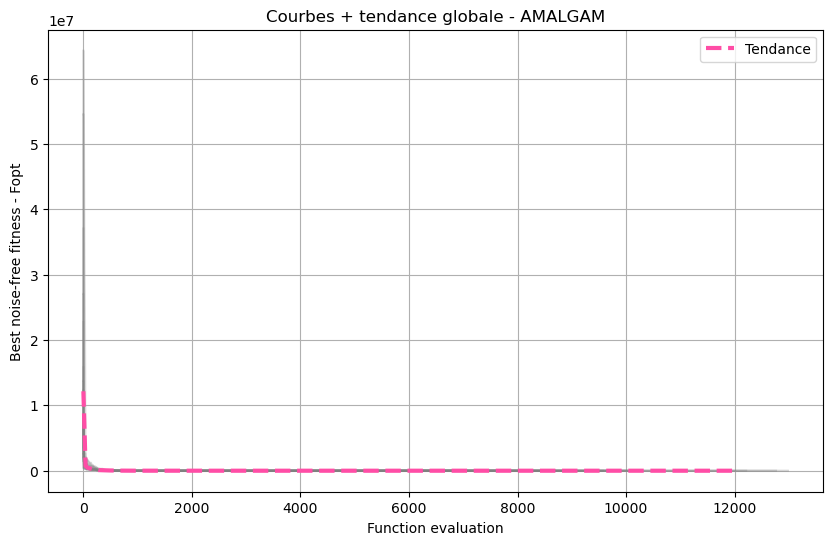

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    if line.startswith("%"):
        if current_run:
            runs.append(current_run)
            current_run = []
    else:
        if line:
            current_run.append(line.split())

if current_run:
    runs.append(current_run)

# 🔥 axe commun
x_common = np.linspace(1, 12000, 300)

ys = []

plt.figure(figsize=(10, 6))

# --- runs + interpolation ---
for run in runs:
    x = np.array([float(row[0]) for row in run])
    y = np.array([float(row[2]) for row in run])

    # tracer les runs (gris léger)
    plt.plot(x, y, color="gray", alpha=0.3)

    # interpolation
    y_interp = np.interp(x_common, x, y)

    # éviter log(0)
    y_interp[y_interp <= 0] = 1e-12

    ys.append(y_interp)

ys = np.array(ys)

# 🔥 moyenne en log (IMPORTANT)
y_mean = np.exp(np.mean(np.log(ys), axis=0))

# bande min/max
y_min = np.min(ys, axis=0)
y_max = np.max(ys, axis=0)

# --- bande ---
plt.fill_between(x_common, y_min, y_max, color="gray", alpha=0.2)

# --- tendance ---
plt.plot(
    x_common,
    y_mean,
    color="#ff4da6",
    linestyle="--",
    linewidth=3,
    label="Tendance"
)


plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbes + tendance globale - AMALGAM")

plt.legend()
plt.grid()
plt.show()

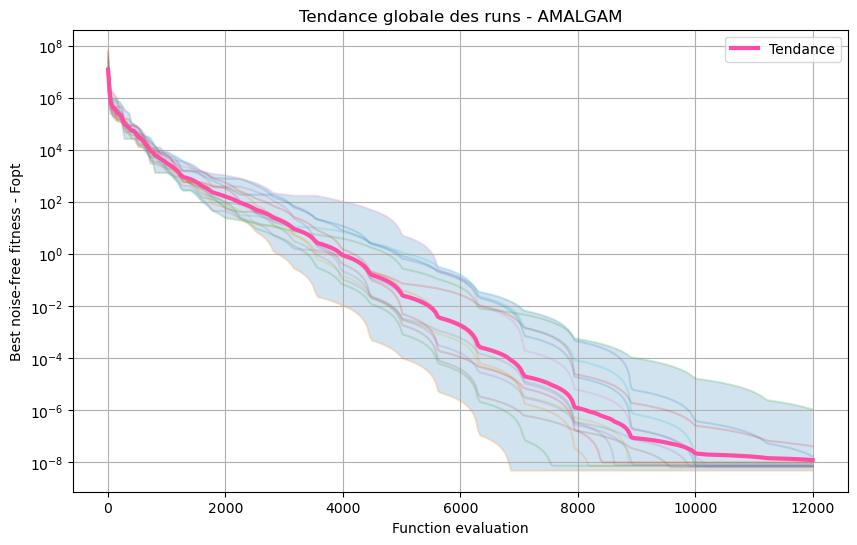

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    if line.startswith("%"):
        if current_run:
            runs.append(current_run)
            current_run = []
    else:
        if line:
            current_run.append(line.split())

if current_run:
    runs.append(current_run)

# axe commun
x_common = np.linspace(1, 12000, 300)

ys = []

for run in runs:
    x = np.array([float(row[0]) for row in run])
    y = np.array([float(row[2]) for row in run])

    # interpolation
    y_interp = np.interp(x_common, x, y)

    # éviter log(0)
    y_interp[y_interp <= 0] = 1e-12

    ys.append(y_interp)

ys = np.array(ys)

#  MOYENNE EN LOG 
y_mean = np.exp(np.mean(np.log(ys), axis=0))

# bande min/max
y_min = np.min(ys, axis=0)
y_max = np.max(ys, axis=0)


plt.figure(figsize=(10,6))

# runs (transparent)
for y in ys:
    plt.plot(x_common, y, alpha=0.2)

# bande
plt.fill_between(x_common, y_min, y_max, alpha=0.2)

# moyenne 
plt.plot(x_common, y_mean, color="#ff4da6", linewidth=3, label="Tendance")

plt.yscale("log")

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Tendance globale des runs - AMALGAM")

plt.legend()
plt.grid()
plt.show()

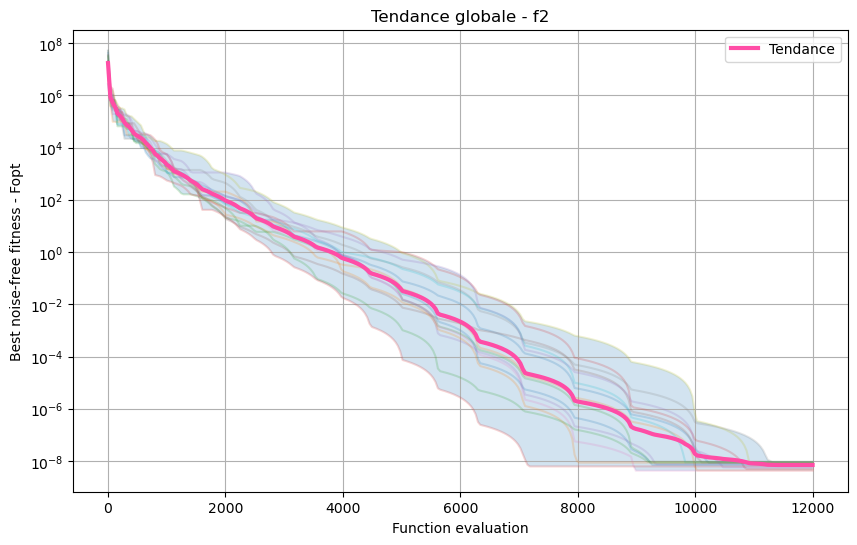

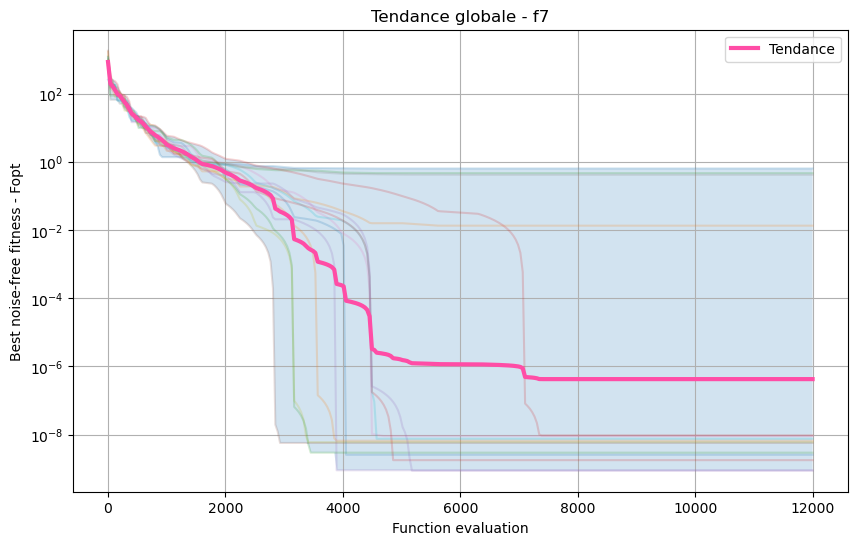

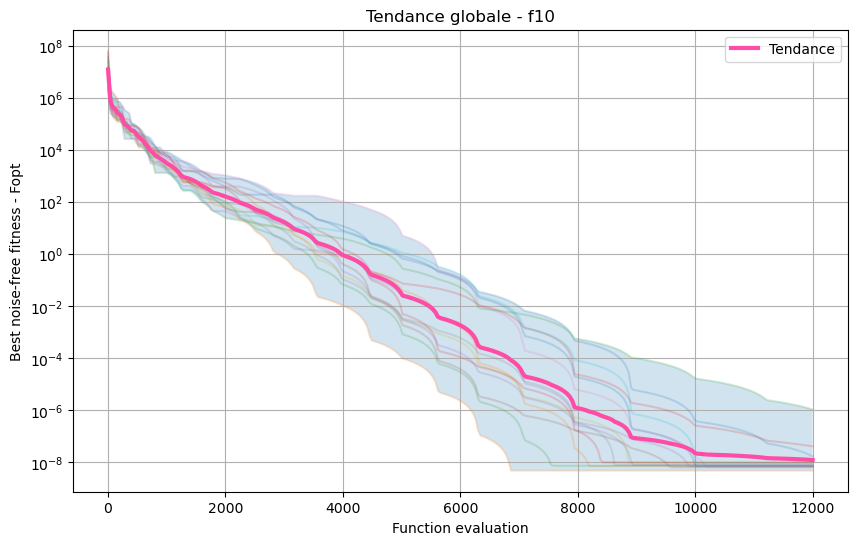

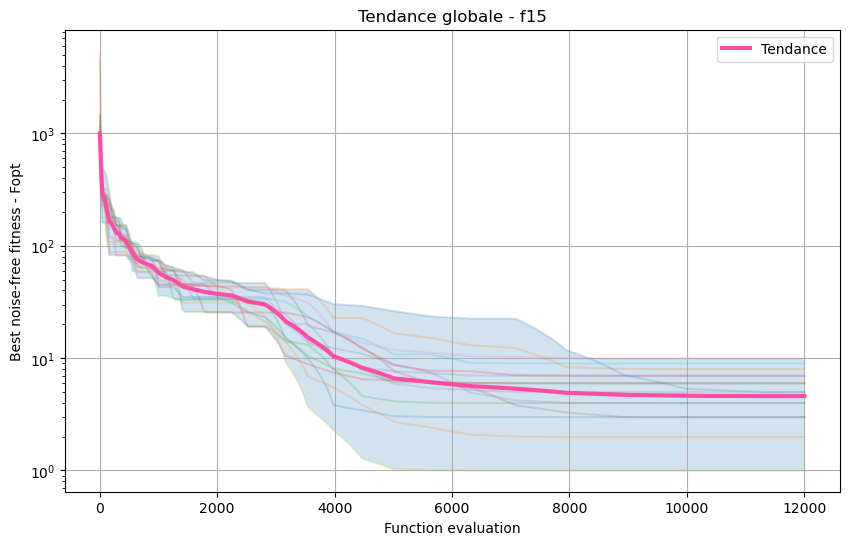

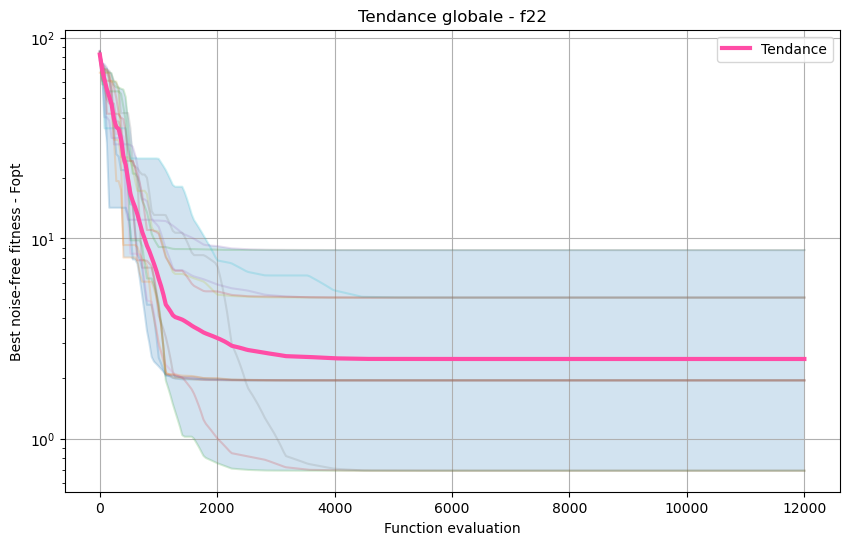

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 🔥 liste des fichiers
files = [
    "bbobexp_f2_DIM10.tdat",
    "bbobexp_f7_DIM10.tdat",
    "bbobexp_f10_DIM10.tdat",
    "bbobexp_f15_DIM10.tdat",
    "bbobexp_f22_DIM10.tdat"
]

for file in files:

    # Lire le fichier
    with open(file, "r") as f:
        lines = f.readlines()

    runs = []
    current_run = []

    for line in lines:
        line = line.strip()

        if line.startswith("%"):
            if current_run:
                runs.append(current_run)
                current_run = []
        else:
            if line:
                current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    # axe commun
    x_common = np.linspace(1, 12000, 300)

    ys = []

    for run in runs:
        x = np.array([float(row[0]) for row in run])
        y = np.array([float(row[2]) for row in run])

        y_interp = np.interp(x_common, x, y)
        y_interp[y_interp <= 0] = 1e-12

        ys.append(y_interp)

    ys = np.array(ys)

    # moyenne log
    y_mean = np.exp(np.mean(np.log(ys), axis=0))

    # min / max
    y_min = np.min(ys, axis=0)
    y_max = np.max(ys, axis=0)

    # --- plot ---
    plt.figure(figsize=(10,6))

    for y in ys:
        plt.plot(x_common, y, alpha=0.2)

    plt.fill_between(x_common, y_min, y_max, alpha=0.2)

    plt.plot(x_common, y_mean, color="#ff4da6", linewidth=3, label="Tendance")

    plt.yscale("log")

    plt.xlabel("Function evaluation")
    plt.ylabel("Best noise-free fitness - Fopt")

    # titre
    problem = file.split("_")[1]   # f2, f7...
    plt.title(f"Tendance globale - {problem}")

    plt.legend()
    plt.grid()
    plt.show()

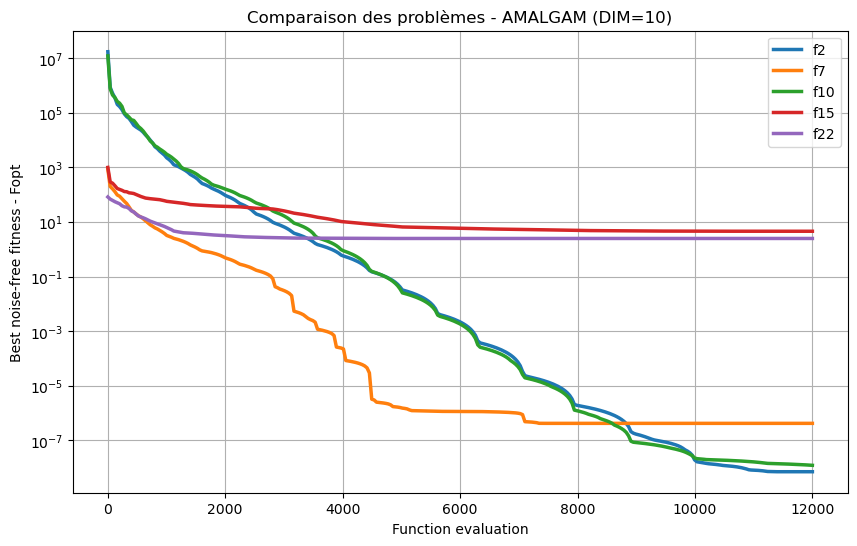

  problem  n_runs    final_mean  final_median    final_best   final_worst
0      f2      15  7.391823e-09  8.170957e-09  4.314771e-09  9.478057e-09
1      f7      15  5.405983e-09  5.968939e-09  8.657111e-10  9.443795e-09
2     f10      15  7.822466e-09  7.839901e-09  4.762995e-09  9.994750e-09
3     f15      15  6.955427e-09  7.397830e-09  3.508546e-09  8.852226e-09
4     f22      15  4.705302e-01  6.918569e-01  2.317371e-09  6.918569e-01
Fichier sauvegardé : resume_problemes_DIM10.csv


In [46]:
import matplotlib.pyplot as plt
import numpy as np

files = [
    "bbobexp_f2_DIM10.tdat",
    "bbobexp_f7_DIM10.tdat",
    "bbobexp_f10_DIM10.tdat",
    "bbobexp_f15_DIM10.tdat",
    "bbobexp_f22_DIM10.tdat"
]

plt.figure(figsize=(10,6))

for file in files:

    with open(file, "r") as f:
        lines = f.readlines()

    runs = []
    current_run = []

    for line in lines:
        line = line.strip()

        if line.startswith("%"):
            if current_run:
                runs.append(current_run)
                current_run = []
        else:
            if line:
                current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    x_common = np.linspace(1, 12000, 300)

    ys = []

    for run in runs:
        x = np.array([float(row[0]) for row in run])
        y = np.array([float(row[2]) for row in run])

        y_interp = np.interp(x_common, x, y)
        y_interp[y_interp <= 0] = 1e-12

        ys.append(y_interp)

    ys = np.array(ys)

    #  tendance (moyenne en log)
    y_mean = np.exp(np.mean(np.log(ys), axis=0))

    # nom du problème
    problem = file.split("_")[1]

    # tracer
    plt.plot(x_common, y_mean, linewidth=2.5, label=problem)

# échelle log obligatoire
plt.yscale("log")

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Comparaison des problèmes - AMALGAM (DIM=10)")

plt.legend()
plt.grid()
plt.show()

# Sauver un petit tableau récapitulatif
# =========================
summary = []

for problem, res in results.items():
    final_values = res["all_interp"][:, -1]  # dernière valeur interpolée

    summary.append({
        "problem": problem,
        "n_runs": len(res["runs"]),
        "final_mean": np.mean(final_values),
        "final_median": np.median(final_values),
        "final_best": np.min(final_values),
        "final_worst": np.max(final_values)
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

summary_df.to_csv("resume_problemes_DIM10.csv", index=False)
print("Fichier sauvegardé : resume_problemes_DIM10.csv")